In [1]:
from pathlib import Path
import json
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [2]:
PROJECT_ROOT = Path.cwd()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

json_file = RAW_DATA_DIR / "games_enriched.json"

with open(json_file, "r", encoding="utf-8") as f:
    games = json.load(f)

records = []

for appid, game in games.items():
    row = game.copy()
    row["appid"] = int(appid)
    records.append(row)

df = pd.DataFrame(records)

print(f"Loaded {len(df):,} games")

Loaded 82,107 games


In [3]:
df["release_date"] = pd.to_datetime(
    df["release_date"],
    errors="coerce"
)

df["release_year"] = (
    df["release_date"]
    .dt.year
    .astype("Int64")
)

for column in ["positive", "negative", "price"]:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    ).fillna(0)

df["positive"] = df["positive"].clip(lower=0)
df["negative"] = df["negative"].clip(lower=0)
df["price"] = df["price"].clip(lower=0)

df["total_reviews"] = (
    df["positive"]
    + df["negative"]
)

REVIEW_MULTIPLIER = 45

df["estimated_revenue"] = (
    df["total_reviews"]
    * REVIEW_MULTIPLIER
    * df["price"]
)

In [4]:
def normalize_tags(value):
    if value is None:
        return []

    if isinstance(value, float) and pd.isna(value):
        return []

    if isinstance(value, dict):
        return [
            str(tag).strip()
            for tag in value.keys()
            if str(tag).strip()
        ]

    if isinstance(value, list):
        return [
            str(tag).strip()
            for tag in value
            if str(tag).strip()
        ]

    if isinstance(value, str):
        value = value.strip()

        if not value:
            return []

        try:
            parsed = ast.literal_eval(value)
        except (ValueError, SyntaxError):
            return []

        if isinstance(parsed, dict):
            return [
                str(tag).strip()
                for tag in parsed.keys()
                if str(tag).strip()
            ]

        if isinstance(parsed, list):
            return [
                str(tag).strip()
                for tag in parsed
                if str(tag).strip()
            ]

    return []


df["tag_list"] = df["tags"].apply(
    normalize_tags
)

df["is_indie"] = df["tag_list"].apply(
    lambda tags: any(
        tag.casefold() == "indie"
        for tag in tags
    )
)

print(
    f"Games currently carrying the Indie tag: "
    f"{df['is_indie'].sum():,}"
)

Games currently carrying the Indie tag: 19,623


In [5]:
TOP_N = 100
TARGET_YEAR = 2025

top_100_indie_2025 = (
    df.loc[
        (df["release_year"] == TARGET_YEAR)
        & df["is_indie"]
        & df["estimated_revenue"].gt(0)
    ]
    .sort_values(
        "estimated_revenue",
        ascending=False
    )
    .head(TOP_N)
    .reset_index(drop=True)
)

top_100_indie_2025["rank"] = (
    top_100_indie_2025.index + 1
)

print(
    f"Selected {len(top_100_indie_2025):,} "
    f"Indie-tagged games from {TARGET_YEAR}"
)

display(
    top_100_indie_2025[
        [
            "rank",
            "name",
            "estimated_revenue",
            "total_reviews",
            "price"
        ]
    ]
    .style
    .format({
        "estimated_revenue": "${:,.0f}",
        "total_reviews": "{:,.0f}",
        "price": "${:.2f}"
    })
    .hide(axis="index")
)

Selected 100 Indie-tagged games from 2025


rank,name,estimated_revenue,total_reviews,price
1,SCUM,"$90,762,698","112,115",$17.99
2,Hades II,"$64,904,791","64,132",$22.49
3,My Summer Car,"$61,649,823","91,394",$14.99
4,Supermarket Simulator,"$43,024,077","68,341",$13.99
5,Escape the Backrooms,"$36,864,302","102,529",$7.99
6,AI LIMIT,"$26,007,120","22,025",$26.24
7,Wobbly Life,"$22,718,502","26,940",$18.74
8,Foundation,"$21,235,234","20,132",$23.44
9,Dinkum,"$17,689,417","24,584",$15.99
10,Rhythm Doctor,"$15,263,814","21,213",$15.99


d:\Workstation\python\steam-analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21688 (\N{CJK UNIFIED IDEOGRAPH-54B8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Workstation\python\steam-analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 40060 (\N{CJK UNIFIED IDEOGRAPH-9C7C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Workstation\python\steam-analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27583 (\N{CJK UNIFIED IDEOGRAPH-6BBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Workstation\python\steam-analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


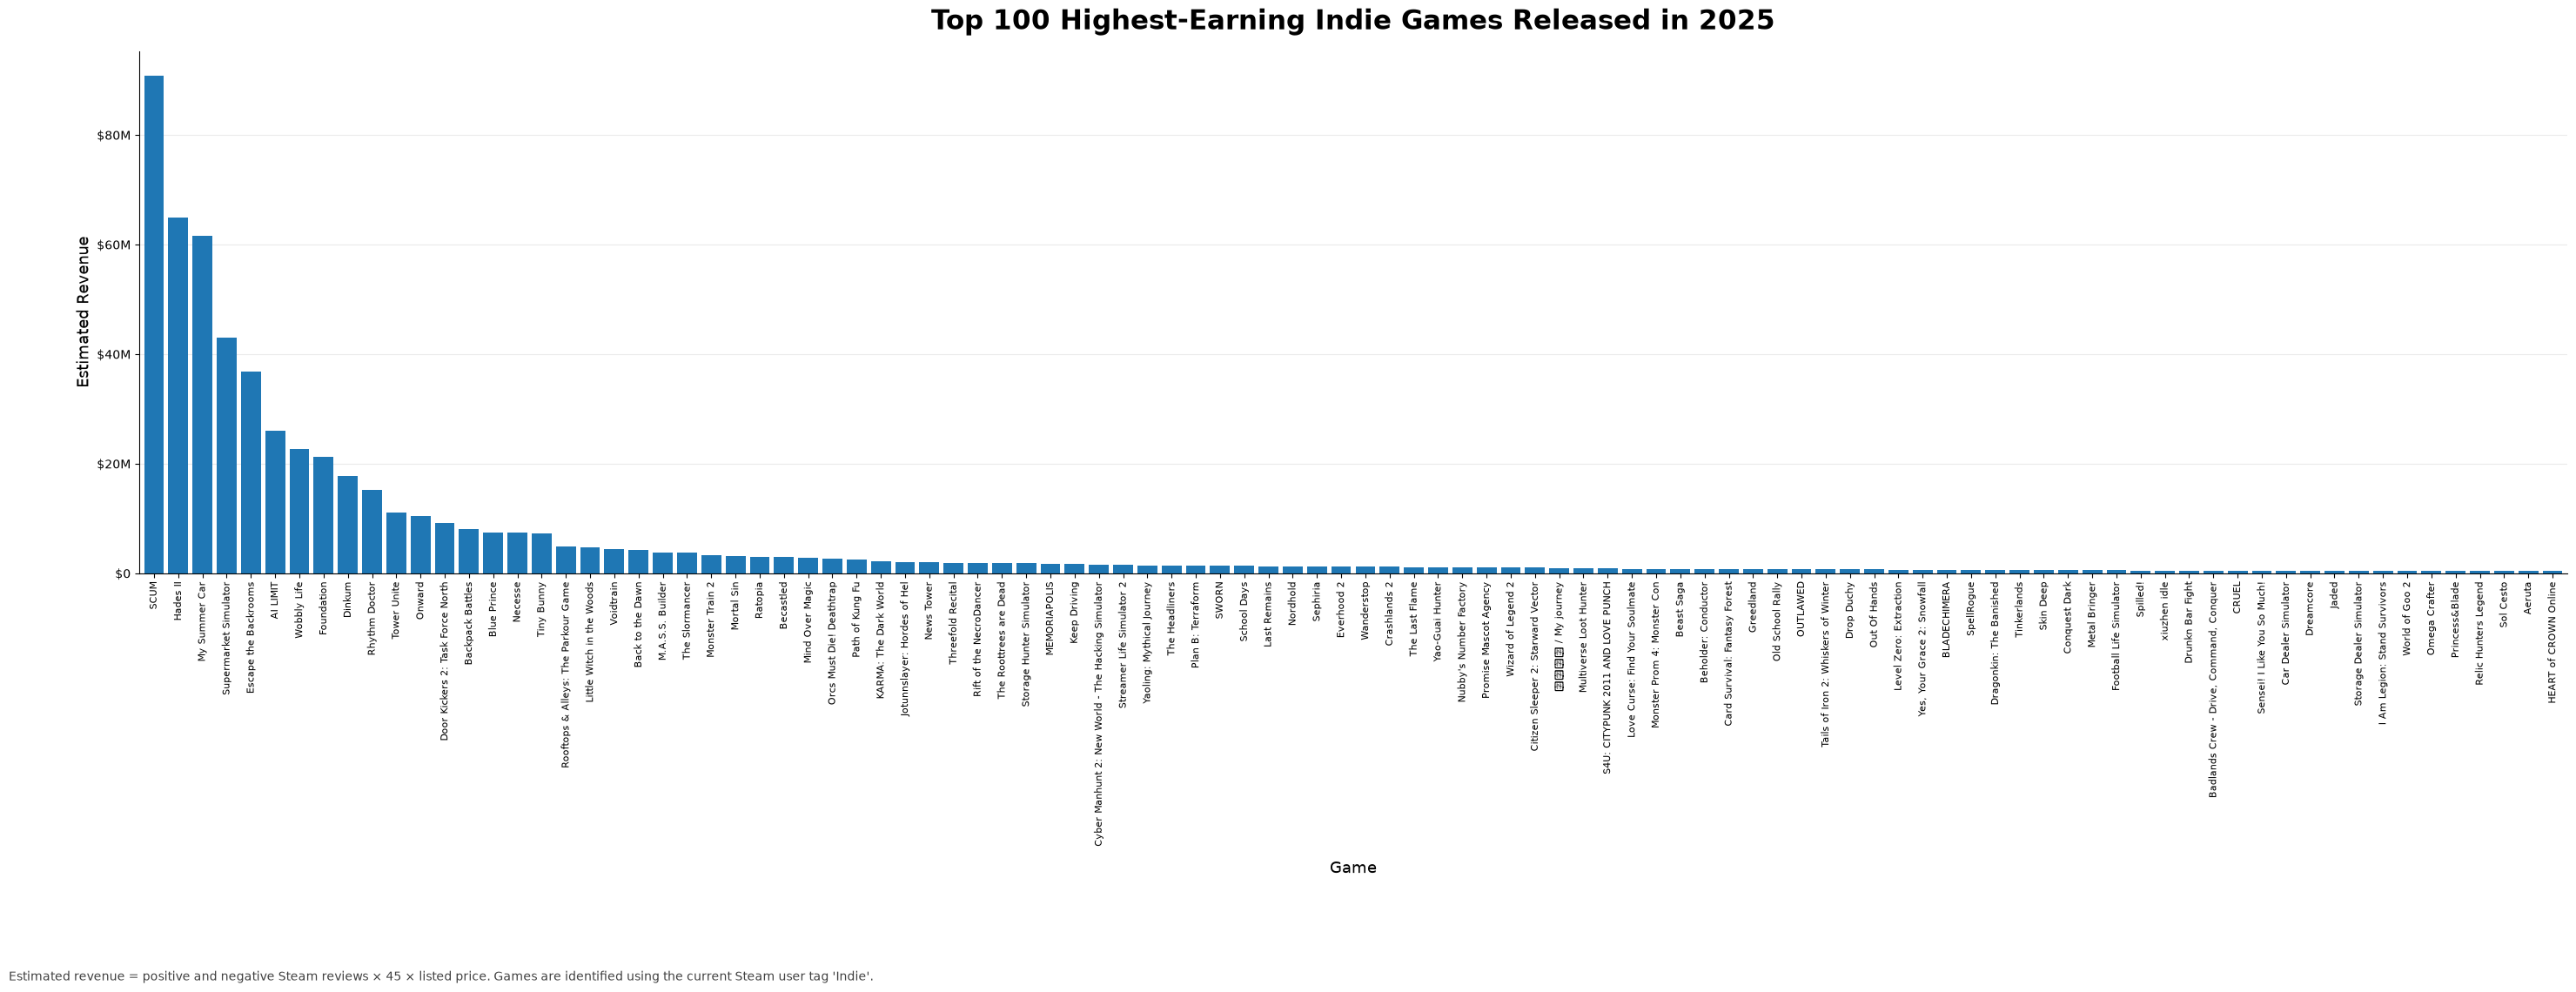

In [6]:
def format_revenue(value, position=None):
    if value >= 1_000_000_000:
        return f"${value / 1_000_000_000:.1f}B"

    if value >= 1_000_000:
        return f"${value / 1_000_000:.0f}M"

    if value >= 1_000:
        return f"${value / 1_000:.0f}K"

    return f"${value:,.0f}"


plot_data = top_100_indie_2025.copy()

fig, ax = plt.subplots(
    figsize=(30, 12)
)

x_positions = np.arange(
    len(plot_data)
)

ax.bar(
    x_positions,
    plot_data["estimated_revenue"],
    width=0.82
)

ax.set_title(
    "Top 100 Highest-Earning Indie Games Released in 2025",
    fontsize=22,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "Game",
    fontsize=13,
    labelpad=12
)

ax.set_ylabel(
    "Estimated Revenue",
    fontsize=13
)

ax.set_xticks(x_positions)

ax.set_xticklabels(
    plot_data["name"],
    rotation=90,
    ha="center",
    va="top",
    fontsize=8
)

ax.yaxis.set_major_formatter(
    FuncFormatter(format_revenue)
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.margins(x=0.002)

fig.text(
    0.01,
    0.01,
    (
        "Estimated revenue = positive and negative Steam reviews × "
        f"{REVIEW_MULTIPLIER} × listed price. "
        "Games are identified using the current Steam user tag 'Indie'."
    ),
    fontsize=10,
    alpha=0.75
)

plt.subplots_adjust(
    left=0.06,
    right=0.99,
    top=0.90,
    bottom=0.40
)

plt.show()

d:\Workstation\python\steam-analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21688 (\N{CJK UNIFIED IDEOGRAPH-54B8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Workstation\python\steam-analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 40060 (\N{CJK UNIFIED IDEOGRAPH-9C7C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Workstation\python\steam-analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27583 (\N{CJK UNIFIED IDEOGRAPH-6BBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Workstation\python\steam-analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


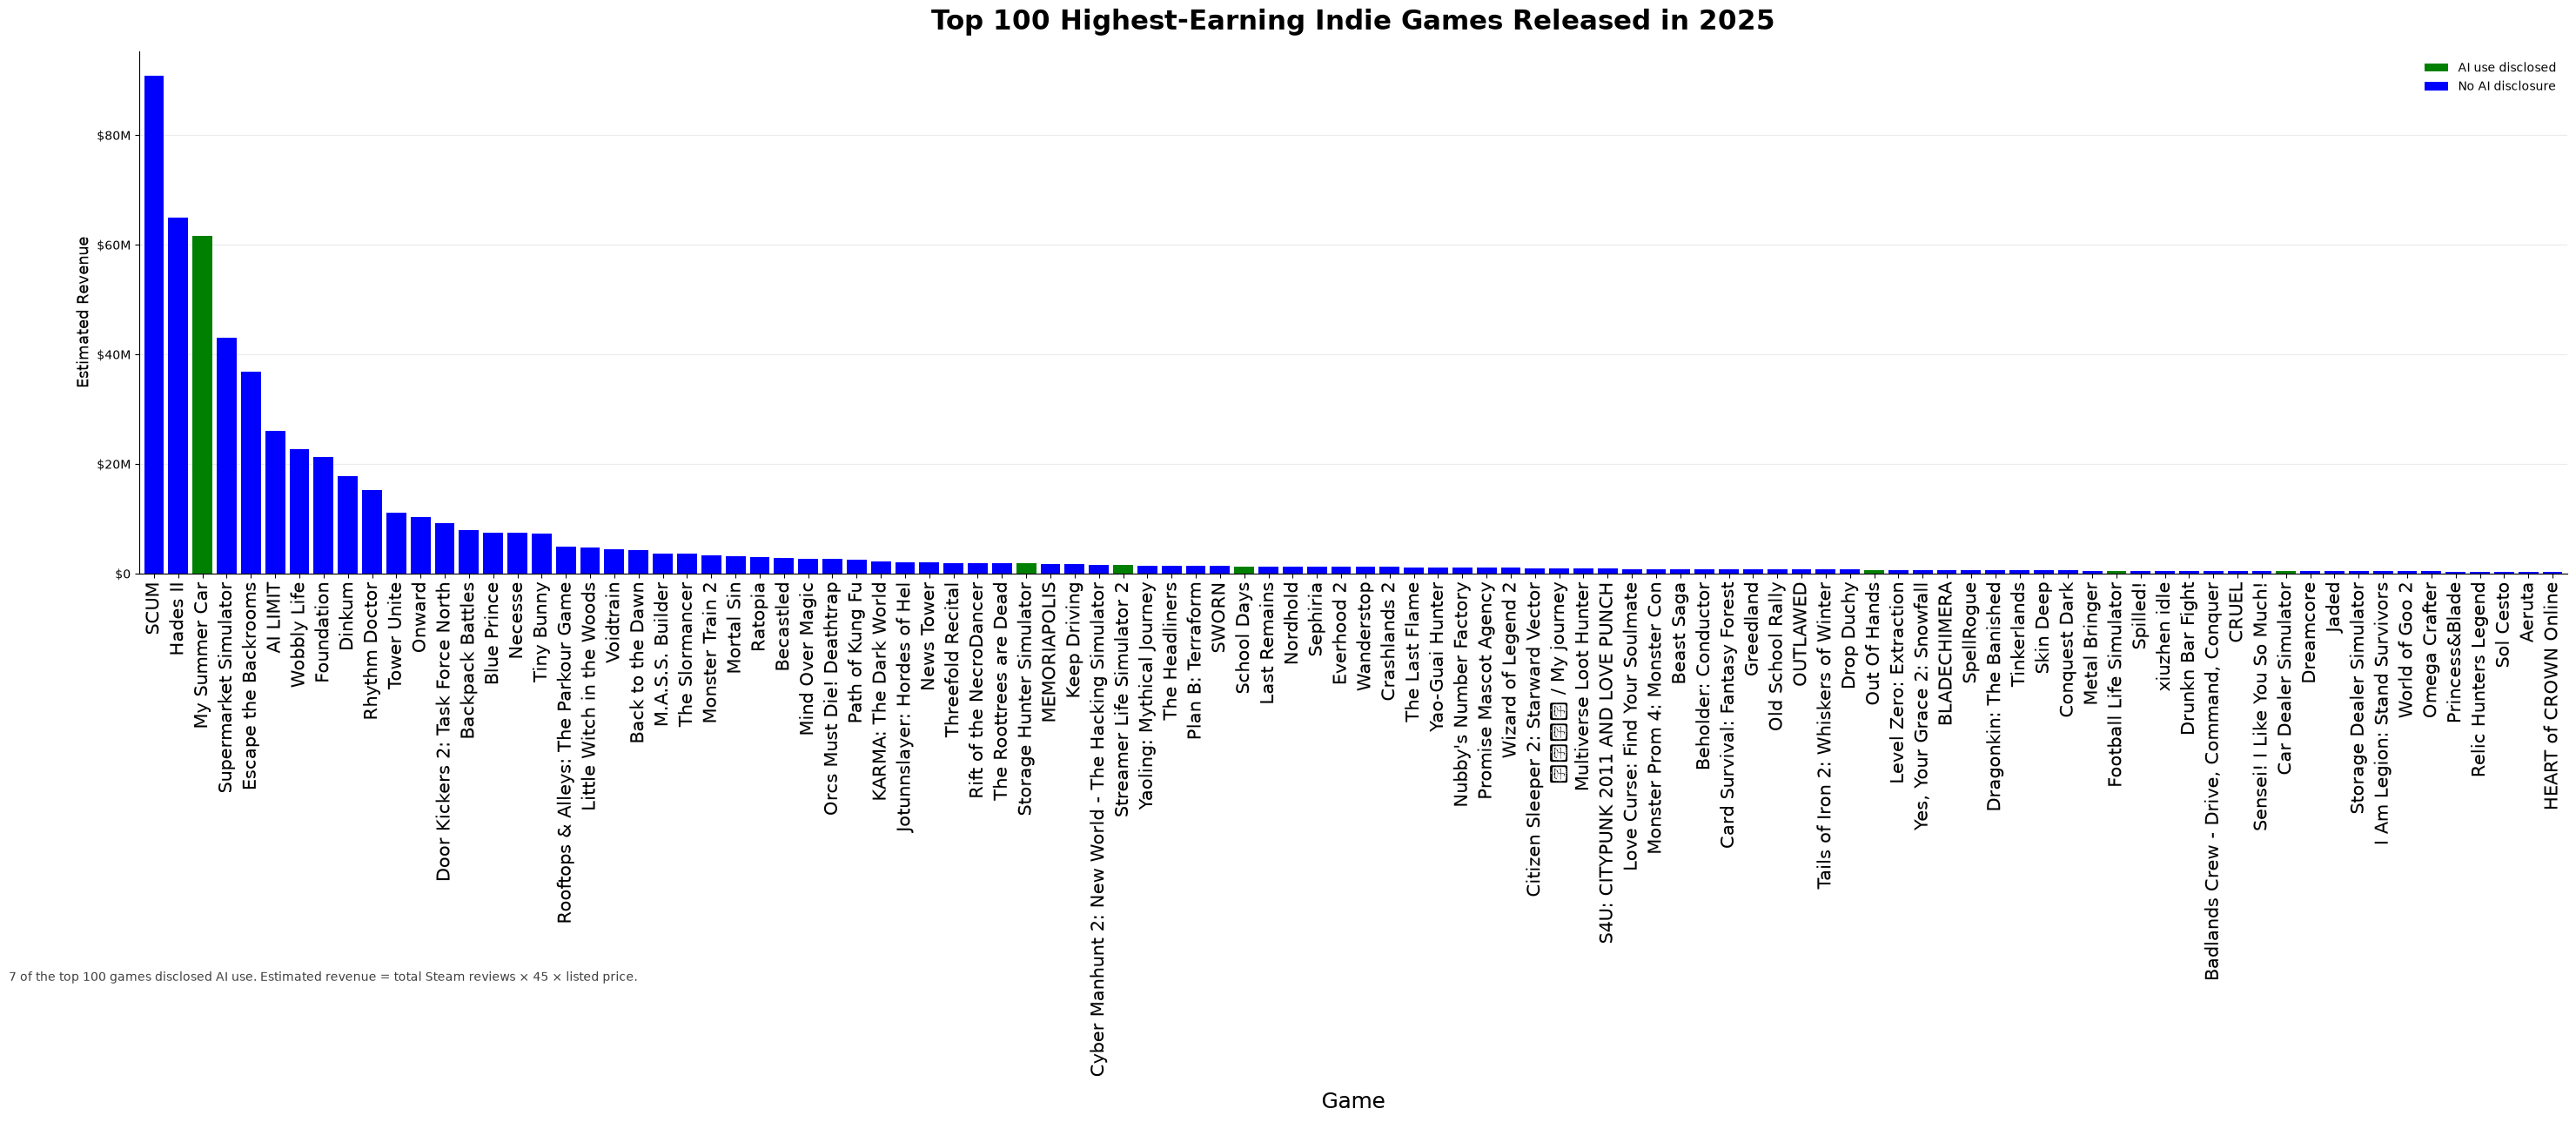

In [10]:
from matplotlib.patches import Patch

plot_data = top_100_indie_2025.copy()

# Safe conversion in case ai_disclosed contains strings
def parse_boolean(value):
    if isinstance(value, bool):
        return value

    if value is None or pd.isna(value):
        return False

    if isinstance(value, (int, float)):
        return value != 0

    if isinstance(value, str):
        return value.strip().casefold() in {
            "true",
            "1",
            "yes",
            "y"
        }

    return False


plot_data["ai_disclosed_clean"] = (
    plot_data["ai_disclosed"]
    .apply(parse_boolean)
)

bar_colors = np.where(
    plot_data["ai_disclosed_clean"],
    "green",
    "blue"
)

fig, ax = plt.subplots(
    figsize=(30, 12)
)

x_positions = np.arange(
    len(plot_data)
)

ax.bar(
    x_positions,
    plot_data["estimated_revenue"],
    width=0.82,
    color=bar_colors
)

ax.set_title(
    "Top 100 Highest-Earning Indie Games Released in 2025",
    fontsize=22,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "Game",
    fontsize=18,
    labelpad=12
)

ax.set_ylabel(
    "Estimated Revenue",
    fontsize=13
)

ax.set_xticks(x_positions)

ax.set_xticklabels(
    plot_data["name"],
    rotation=90,
    ha="center",
    va="top",
    fontsize=15
)

ax.yaxis.set_major_formatter(
    FuncFormatter(format_revenue)
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.margins(x=0.002)

legend_items = [
    Patch(
        facecolor="green",
        label="AI use disclosed"
    ),
    Patch(
        facecolor="blue",
        label="No AI disclosure"
    )
]

ax.legend(
    handles=legend_items,
    frameon=False,
    loc="upper right"
)

ai_count = int(
    plot_data["ai_disclosed_clean"].sum()
)

fig.text(
    0.01,
    0.01,
    (
        f"{ai_count} of the top {len(plot_data)} games disclosed AI use. "
        "Estimated revenue = total Steam reviews × "
        f"{REVIEW_MULTIPLIER} × listed price."
    ),
    fontsize=10,
    alpha=0.75
)

plt.subplots_adjust(
    left=0.06,
    right=0.99,
    top=0.90,
    bottom=0.40
)

plt.show()

d:\Workstation\python\steam-analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21688 (\N{CJK UNIFIED IDEOGRAPH-54B8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Workstation\python\steam-analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 40060 (\N{CJK UNIFIED IDEOGRAPH-9C7C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Workstation\python\steam-analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27583 (\N{CJK UNIFIED IDEOGRAPH-6BBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Workstation\python\steam-analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


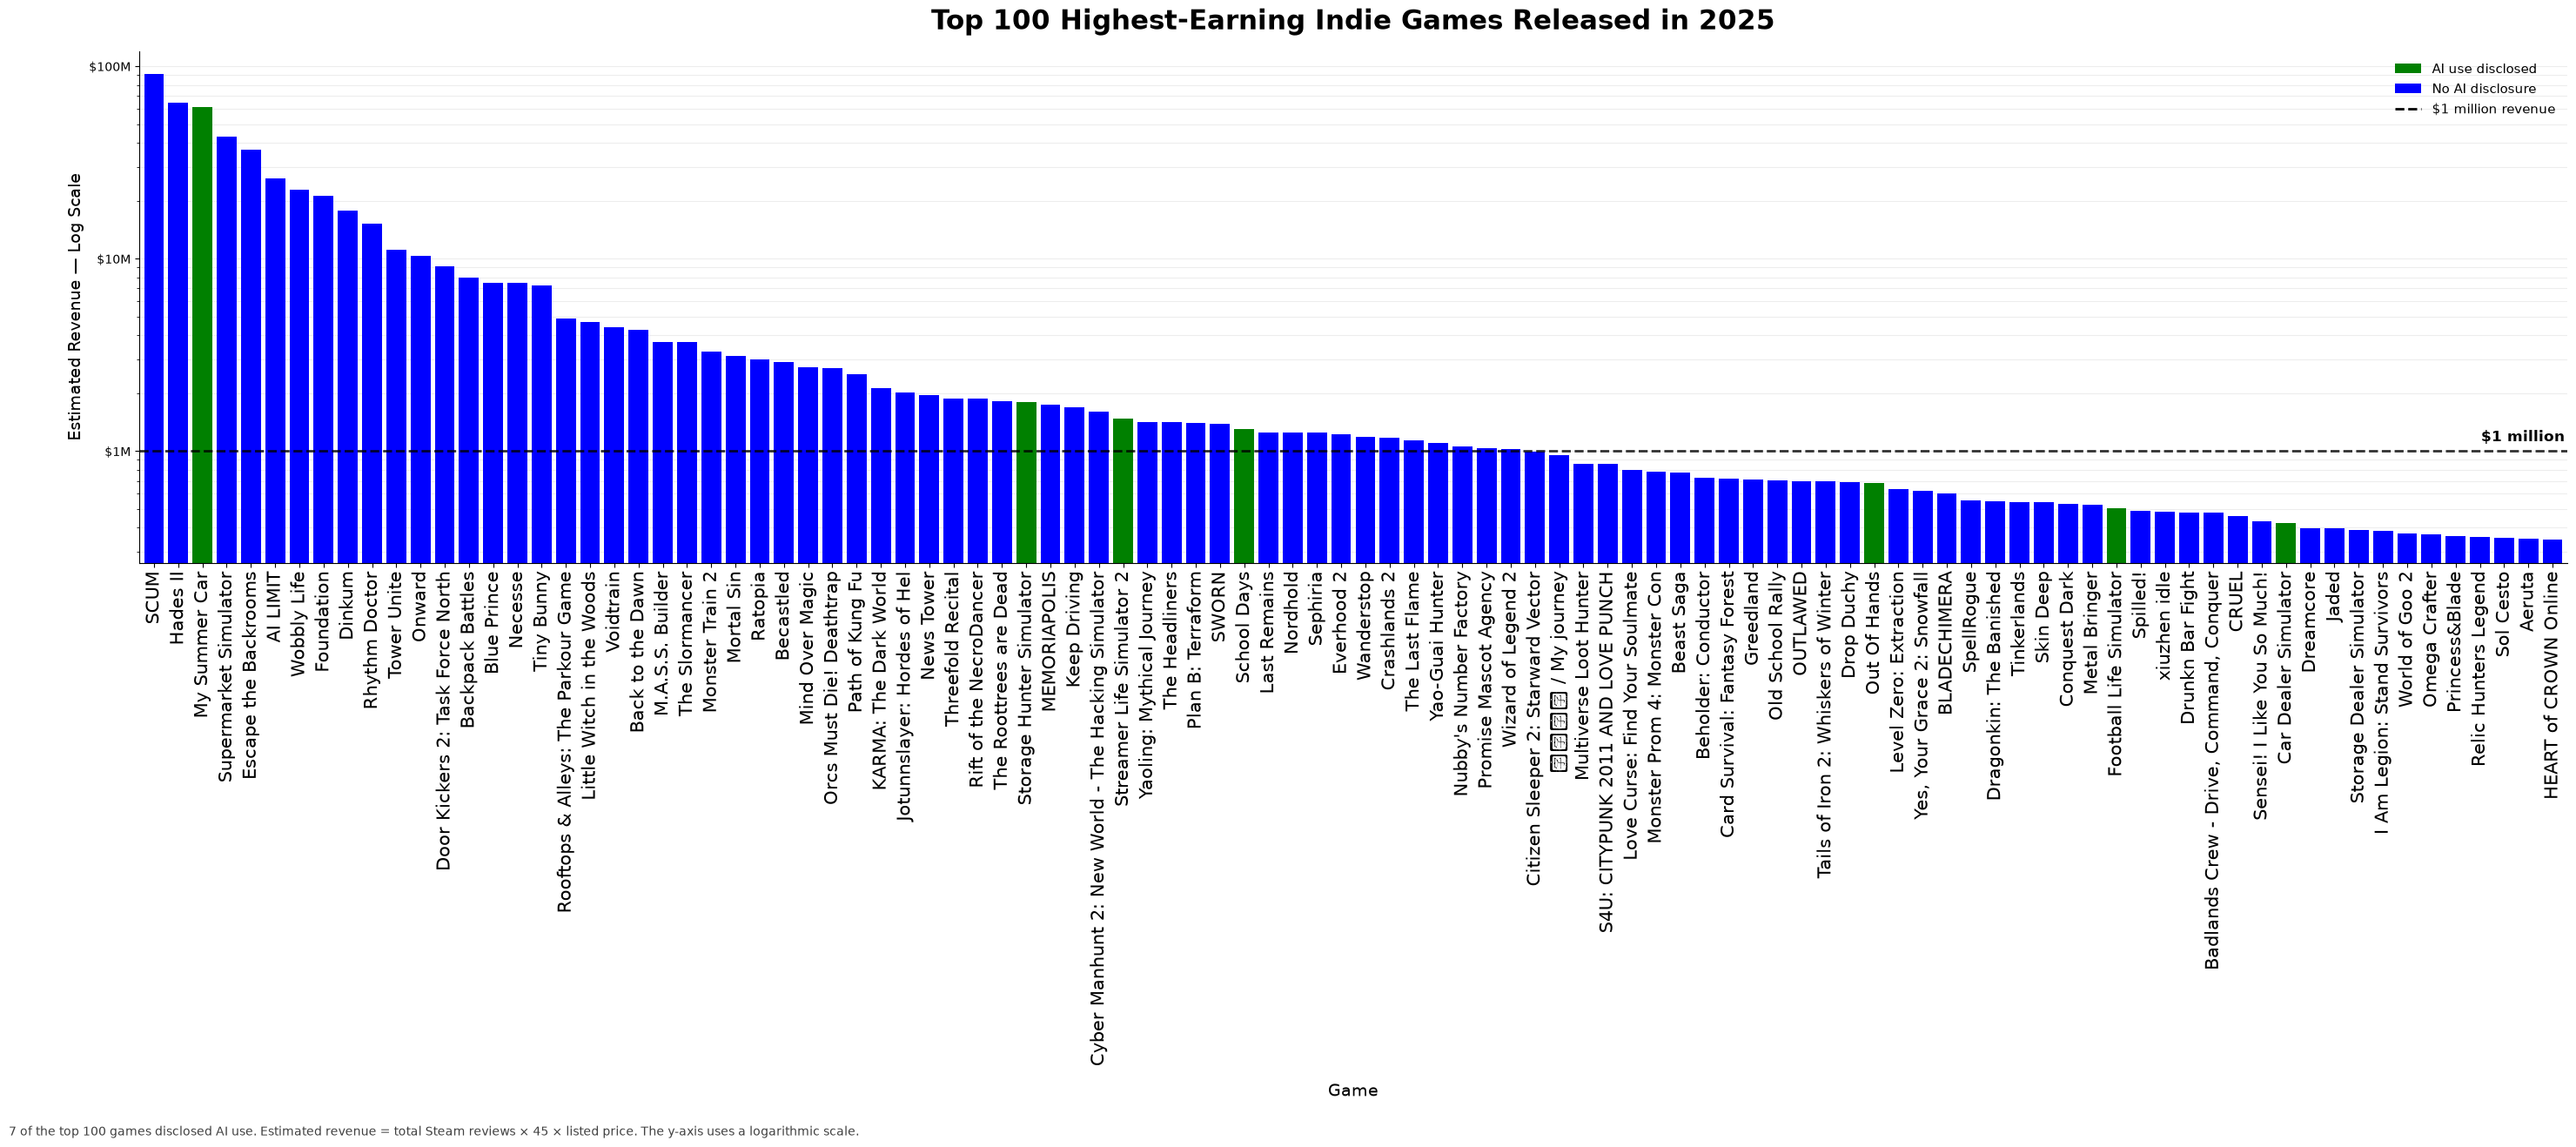

In [12]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, LogLocator

plot_data = top_100_indie_2025.copy()

def parse_boolean(value):
    if isinstance(value, bool):
        return value

    if value is None or pd.isna(value):
        return False

    if isinstance(value, (int, float)):
        return value != 0

    if isinstance(value, str):
        return value.strip().casefold() in {
            "true",
            "1",
            "yes",
            "y"
        }

    return False


plot_data["ai_disclosed_clean"] = (
    plot_data["ai_disclosed"]
    .apply(parse_boolean)
)

bar_colors = np.where(
    plot_data["ai_disclosed_clean"],
    "green",
    "blue"
)

fig, ax = plt.subplots(
    figsize=(30, 14)
)

x_positions = np.arange(
    len(plot_data)
)

ax.bar(
    x_positions,
    plot_data["estimated_revenue"],
    width=0.82,
    color=bar_colors
)

# Logarithmic revenue scale
ax.set_yscale("log")

# $1 million reference line
MILLION_DOLLAR_LINE = 1_000_000

ax.axhline(
    MILLION_DOLLAR_LINE,
    linestyle="--",
    linewidth=2,
    color="black",
    alpha=0.8,
    zorder=3
)

# Add label directly above the line
ax.text(
    len(plot_data) - 0.5,
    MILLION_DOLLAR_LINE * 1.08,
    "$1 million",
    ha="right",
    va="bottom",
    fontsize=12,
    fontweight="bold"
)

ax.set_title(
    "Top 100 Highest-Earning Indie Games Released in 2025",
    fontsize=22,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "Game",
    fontsize=14,
    labelpad=14
)

ax.set_ylabel(
    "Estimated Revenue — Log Scale",
    fontsize=14
)

ax.set_xticks(x_positions)

ax.set_xticklabels(
    plot_data["name"],
    rotation=90,
    ha="center",
    va="top",
    fontsize=15
)

def format_log_revenue(value, position=None):
    if value >= 1_000_000_000:
        return f"${value / 1_000_000_000:g}B"

    if value >= 1_000_000:
        return f"${value / 1_000_000:g}M"

    if value >= 1_000:
        return f"${value / 1_000:g}K"

    return f"${value:g}"


ax.yaxis.set_major_formatter(
    FuncFormatter(format_log_revenue)
)

ax.yaxis.set_major_locator(
    LogLocator(
        base=10,
        subs=(1.0,)
    )
)

ax.grid(
    axis="y",
    which="both",
    alpha=0.22
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.margins(x=0.002)

legend_items = [
    Patch(
        facecolor="green",
        label="AI use disclosed"
    ),
    Patch(
        facecolor="blue",
        label="No AI disclosure"
    ),
    Line2D(
        [0],
        [0],
        color="black",
        linewidth=2,
        linestyle="--",
        label="$1 million revenue"
    )
]

ax.legend(
    handles=legend_items,
    frameon=False,
    loc="upper right",
    fontsize=11
)

ai_count = int(
    plot_data["ai_disclosed_clean"].sum()
)

fig.text(
    0.01,
    0.01,
    (
        f"{ai_count} of the top {len(plot_data)} games disclosed AI use. "
        "Estimated revenue = total Steam reviews × "
        f"{REVIEW_MULTIPLIER} × listed price. "
        "The y-axis uses a logarithmic scale."
    ),
    fontsize=10,
    alpha=0.75
)

plt.subplots_adjust(
    left=0.06,
    right=0.99,
    top=0.90,
    bottom=0.48
)

plt.show()